# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para mejores gráficos
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Configuración para mostrar más columnas y filas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')    

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
print("Cantidad de nulos para users:")
print(users.isnull().sum())

print("Proporción de valores nulos:")
print(users.isnull().mean())

Cantidad de nulos para users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print("Cantidad de nulos para users:")
print(usage.isnull().sum())
print("Proporción de valores nulos:")
print(usage.isnull().mean())


Cantidad de nulos para users:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Para el dataset users:
- city: 11.7% de nulos (469 de 4000 usuarios)- IMPUTAR
- churn_date: 88.4% de nulos (3534 de 4000 usuarios) -IGNORAR

Para el dataset usage:
- date: 0.1% de nulos (50 de 40000 registros) - ELIMINAR
- duration: 55.2% de nulos (22076 de 40000 registros) -IGNORAR
- length: 44.7% de nulos (17896 de 40000 registros) - IGNORAR


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:


# explorar columnas numéricas de users
print("Resumen estadístico de users:")
users.describe()



Resumen estadístico de users:


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`  no tiene valores negativos o extraños
- La columna `age` tiene un sentinel con  el valor -999

In [13]:
# explorar columnas numéricas de usage
# explorar columnas numéricas de usage
print("Resumen estadístico de usage:")
usage.describe()

Resumen estadístico de usage:


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


In [14]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print("=== COLUMNA CITY ===")
print("Valores únicos en city:")
print(users['city'].value_counts())
print(f"\nTotal de valores únicos: {users['city'].nunique()}")

print("\n=== COLUMNA PLAN ===")
print("Valores únicos en plan:")
print(users['plan'].value_counts())
print(f"\nTotal de valores únicos: {users['plan'].nunique()}")

=== COLUMNA CITY ===
Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Total de valores únicos: 7

=== COLUMNA PLAN ===
Valores únicos en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Total de valores únicos: 2


- La columna `city` ...
- La columna `plan` ...

In [15]:
# explorar columna categórica de usage
usage['type'] # completa el código

0        call
1        text
2        text
3        call
4        call
         ... 
39995    call
39996    call
39997    call
39998    text
39999    call
Name: type, Length: 40000, dtype: object

- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? En la columna age hay un sentinel -999, en la columna city identifiqué "?"
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])


In [17]:
# Verificar el tipo de datos
print("Tipo de datos de reg_date:", users['reg_date'].dtype)
print("Primeras 5 fechas:")
print(users['reg_date'].head())

Tipo de datos de reg_date: datetime64[ns]
Primeras 5 fechas:
0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]


In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [19]:
# Verificar el tipo de datos
print("Tipo de datos de date:", usage['date'].dtype)
print("Primeras 5 fechas:")
print(usage['date'].head())

Tipo de datos de date: datetime64[ns]
Primeras 5 fechas:
0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]


In [20]:
# Revisar los años presentes en `reg_date` de users
años_reg = users['reg_date'].dt.year
print("Años únicos en reg_date:")
print(años_reg.value_counts().sort_index())


Años únicos en reg_date:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
Según las instrucciones, los datos están registrados hasta el 2024, no obstante, aparecen 40 registros en el 2026, lo cual puede ser un error en la captura o procesamiento de datos. Deberían marcarse como nulos para mantener la integridad del análisis

In [21]:
# Revisar los años presentes en `date` de usage
años_usage = usage['date'].dt.year
print("Años únicos en date:")
print(años_usage.value_counts().sort_index())


Años únicos en date:
2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas. Aparece únicamente el año 2024 con 39950 registros. Aunque los usuarios se registraron de 2022 a 2024, en esta parte solo aparece cuándo usaron el servicio que fue el año que indica.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Se identifican fechas imposibles (2.26) porque son fechas a futuro dado que el dataset trabaja hasta el año 2024

Para los 40 registros con fecha 2026 lo indicado sería convertir a valores nulos (pd.NA)

Justificación: 
- Representa solo el 1% de los datos (40 de 4,000 usuarios)
- Son fechas imposibles que probablemente resultan de errores de captura o procesamiento
- Mantener la integridad temporal del análisis es crucial
- Al ser un porcentaje pequeño, no afectará significativamente el análisis

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:

# Reemplazar -999 por la mediana de age
age_mediana = users['age'][users['age'] != -999].median()
users['age'] = users['age'].replace(-999, age_mediana)
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
print("Valores únicos en city después de limpieza:")
print(users['city'].value_counts(dropna=False))

Valores únicos en city después de limpieza:
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [24]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
# Verificar cambios
print("Años únicos después de limpieza:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años únicos después de limpieza:
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
print("=== Análisis MAR para duration ===")
print("Distribución de nulos en duration por tipo:")
mar_analysis = usage.groupby('type')['duration'].agg(['count', lambda x: x.isnull().sum()])
mar_analysis.columns = ['total_registros', 'nulos']
mar_analysis['porcentaje_nulos'] = (mar_analysis['nulos'] / mar_analysis['total_registros']) * 100
print(mar_analysis)


=== Análisis MAR para duration ===
Distribución de nulos en duration por tipo:
      total_registros    nulos  porcentaje_nulos
type                                            
call            17908      0.0               0.0
text               16  22076.0          137975.0


In [26]:
# Verificación MAR en usage (Missing At Random) para length
print("=== Análisis MAR para length ===")
print("Distribución de nulos en length por tipo:")
mar_analysis_length = usage.groupby('type')['length'].agg(['count', lambda x: x.isnull().sum()])
mar_analysis_length.columns = ['total_registros', 'nulos']
mar_analysis_length['porcentaje_nulos'] = (mar_analysis_length['nulos'] / mar_analysis_length['total_registros']) * 100
print(mar_analysis_length)


=== Análisis MAR para length ===
Distribución de nulos en length por tipo:
      total_registros    nulos  porcentaje_nulos
type                                            
call               12  17896.0     149133.333333
text            22092      0.0          0.000000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Los registros de tipo "text" tienen valores en length (pocos nulos) porque los mensajes sí tienen longitud
Los registros de tipo "call" tienen muchos nulos en length (porque las llamadas no tienen longitud de texto)
Esto confirma que los nulos en ambas columnas (duration y length) son MAR y justifica mantenerlos como nulos

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',           # suma total de mensajes
    'is_call': 'sum',           # suma total de llamadas  
    'duration': 'sum'           # suma total de minutos
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas', 
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:

# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [31]:

# Distribución del tipo de plan
print("Conteos:")
print(user_profile['plan'].value_counts())
print("\nPorcentajes:")
print(user_profile['plan'].value_counts(normalize=True) * 100)

Conteos:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Porcentajes:
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

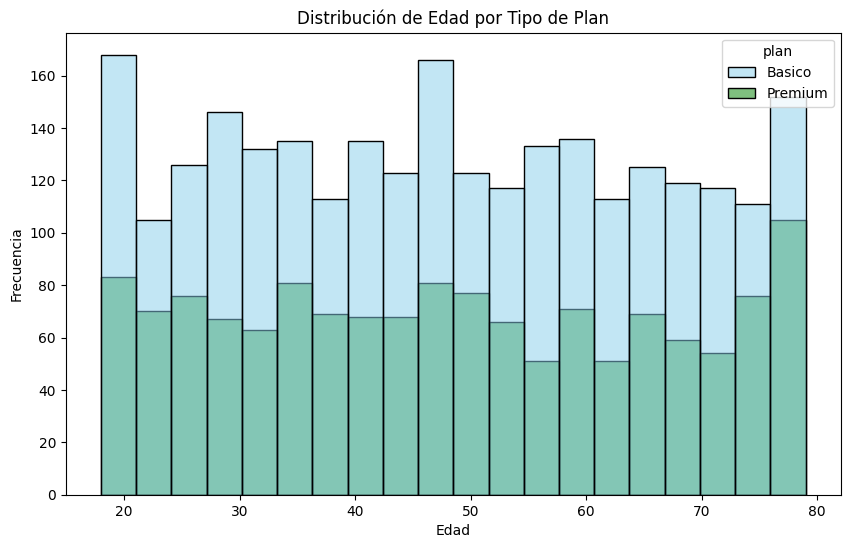

In [32]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], bins=20)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- El Plan Básico tiene un volumen significativamente mayor de usuarios en casi todos los rangos de edad en comparación con el Plan Premium.
- La base de usuarios está dominada por el plan económico, lo cual es normal.
- Los usuarios de mayor edad muestra tienen una alta disposición a contratar el Plan Premium debido a que podría ser un segmento con mayor poder adquisitivo o lealtad a largo plazo.

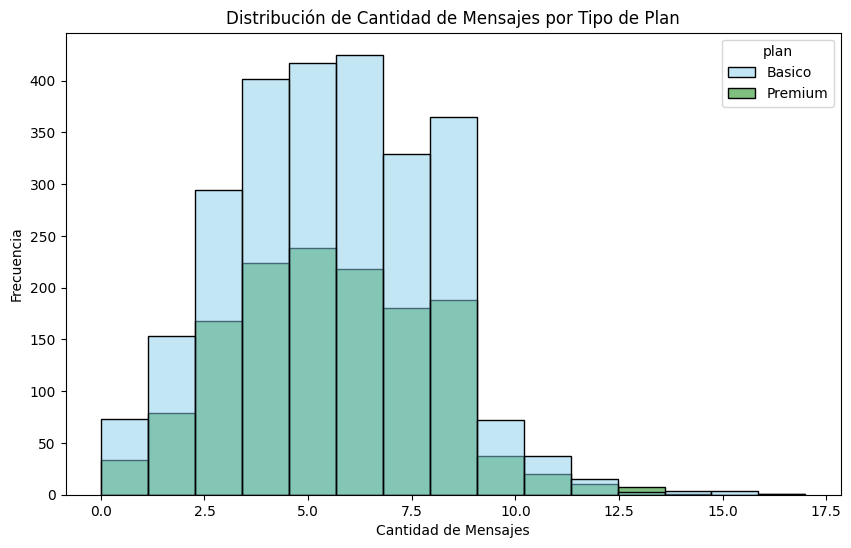

In [33]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], bins=15)
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- Está un poco sesgada a la derecha.
- La gran mayoría de los usuarios, independientemente del plan, envía entre 3 y 8 mensajes.
- El comportamiento de uso no cambia según el plan. Un usuario Premium no necesariamente envía más mensajes que uno Básico.
- Cualquier usuario que envíe más de 10 mensajes ya está fuera de la norma (outlier), lo que podría usarse para identificar comportamientos inusuales o perfiles muy activos para campañas de fidelización.

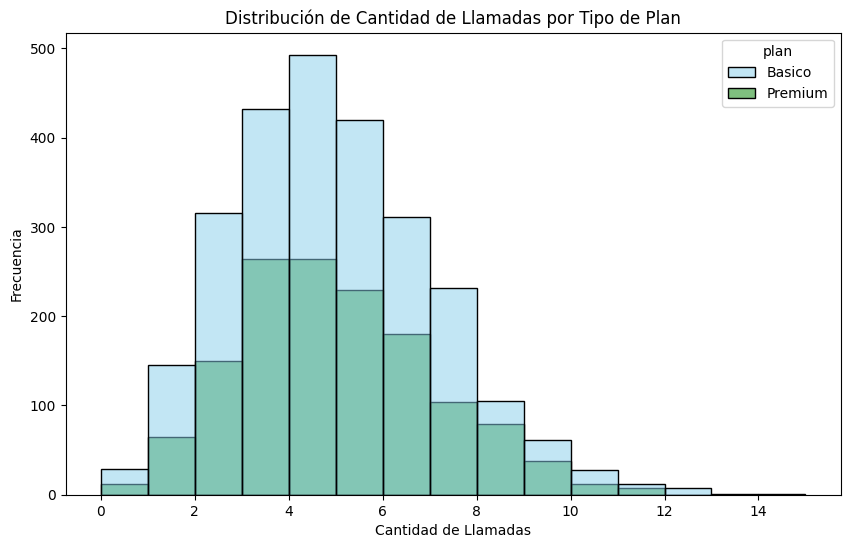

In [34]:

# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], bins=15)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La mayoría de los usuarios no son hablan mucho, las llamadas parecen ser breves o puntuales.
- Los usuarios que realizan una cantidad moderada de llamadas (entre 3 y 6) parecen ser los más propensos a tener el Plan Premium.
- Muy pocos usuarios superan las 10 llamadas. Aquellos que llegan a 12 o 14 son casos aislados.
- Los usuarios interactúan más mediante mensajes que mediante llamadas.

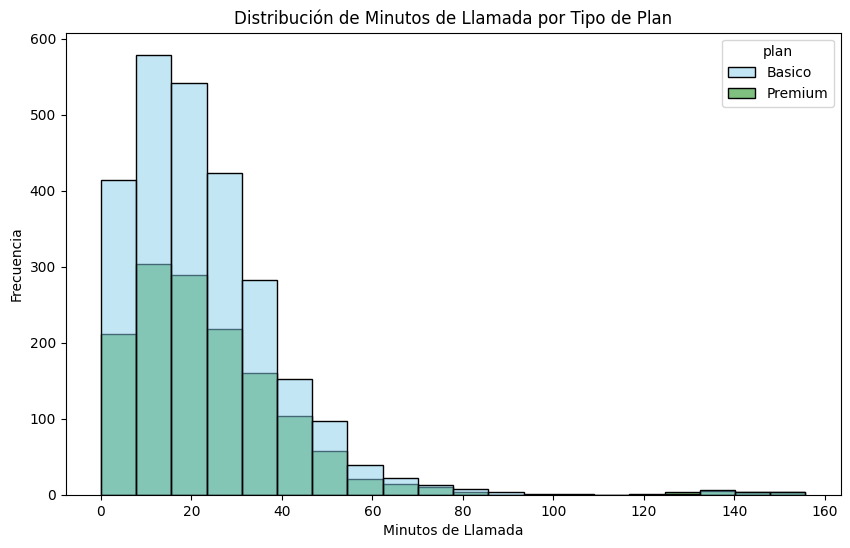

In [35]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], bins=20)
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

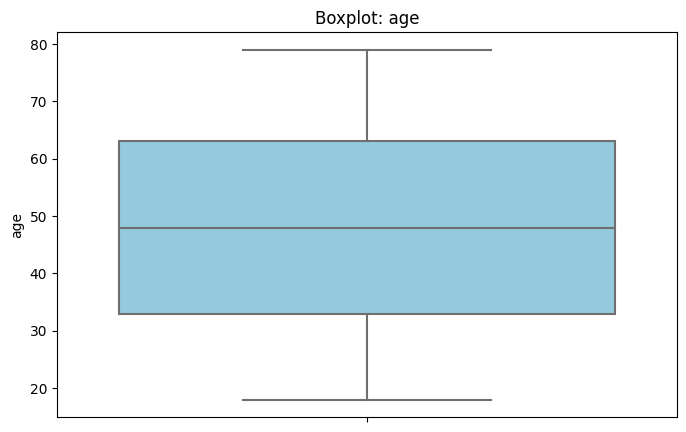

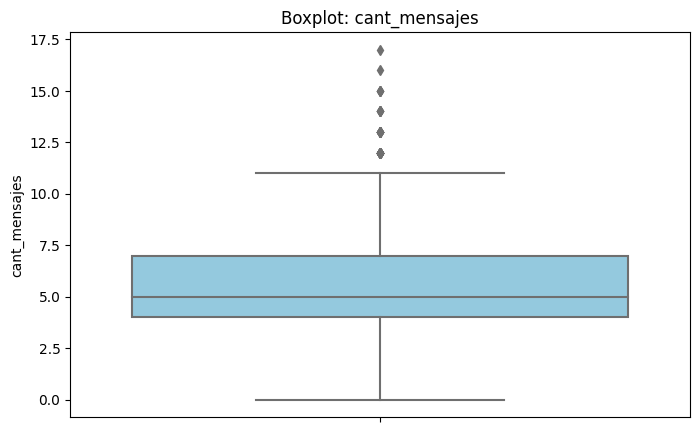

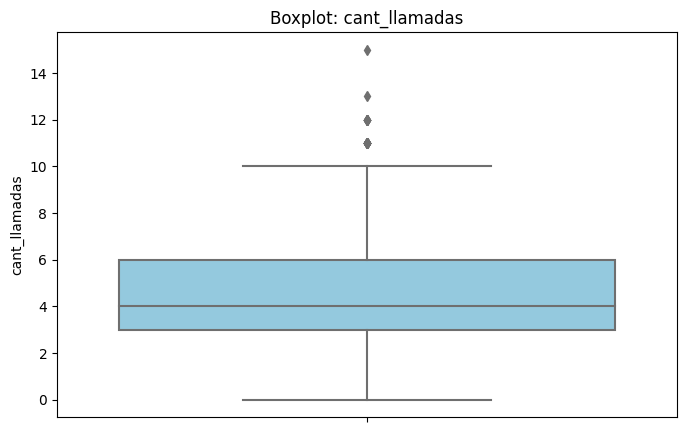

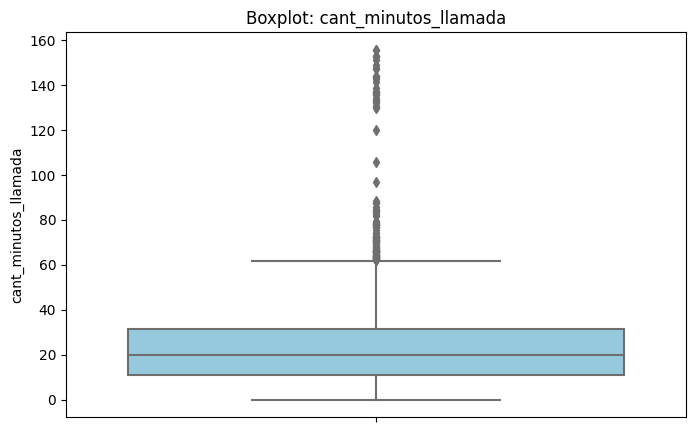

In [39]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=user_profile, y=col, hue='plan', palette=['skyblue','green'])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers significativos.
- cant_mensajes: Presenta outliers superiores (usuarios que envían más de 10-12 mensajes).
- cant_llamadas: Presenta outliers superiores (usuarios con más de 8-10 llamadas).
- cant_minutos_llamada: Presenta outliers superiores importantes (usuarios con más de 60-80 minutos).

In [41]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']



In [42]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantener outliers, porque los valores extremos (10-17 mensajes) son realistas para usuarios muy activos; representan un segmento valioso de "heavy users" que podrían ser candidatos para planes premium; además que no parecen errores de datos sino comportamiento genuino
cant_llamadas: Mantener outliers porque los valores altos (10-15 llamadas) son plausibles para usuarios con alta actividad telefónica. Estos usuarios podrían ser profesionales o empresarios que usan mucho el teléfono.
- cant_minutos_llamada: Mantener outliers porque aunque 155 minutos parece alto, es factible (aproximadamente 2.5 horas de llamadas). Estos usuarios representan el mayor valor para la empresa (alto consumo) y son candidatos ideales para planes ilimitados o tarifas corporativas.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [43]:
# Crear columna grupo_uso
import numpy as np

# Definir condiciones y resultados
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
valores = ['Bajo uso', 'Uso medio']

# Asignar grupo_uso; lo que no cumple cae en 'Alto uso'
user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')

In [44]:
# verificar cambios
user_profile[['cant_llamadas','cant_mensajes','grupo_uso']].head(10)

,cant_llamadas,cant_mensajes,grupo_uso
0,3.0,7.0,Uso medio
1,10.0,5.0,Alto uso
2,2.0,5.0,Uso medio
3,3.0,11.0,Alto uso
4,3.0,4.0,Bajo uso
5,7.0,5.0,Uso medio
6,5.0,3.0,Uso medio
7,5.0,3.0,Uso medio
8,5.0,5.0,Uso medio
9,3.0,5.0,Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [45]:
# Crear columna grupo_edad
# Definir condiciones y resultados
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]
valores_edad = ['Joven', 'Adulto']

# Asignar grupo_edad; lo que no cumple cae en 'Adulto Mayor'
user_profile['grupo_edad'] = np.select(condiciones_edad, valores_edad, default='Adulto Mayor')


In [46]:
# verificar cambios
user_profile[['age','grupo_edad']].head(10)

,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor
5,61.0,Adulto Mayor
6,39.0,Adulto
7,70.0,Adulto Mayor
8,76.0,Adulto Mayor
9,47.0,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

Text(0, 0.5, 'Cantidad de Usuarios')

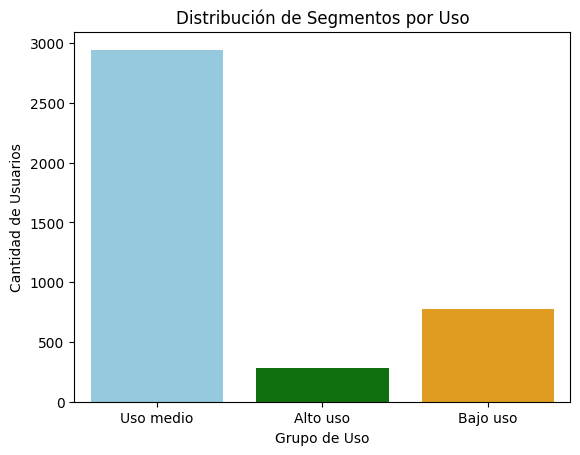

In [48]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue','green','orange'])
plt.title('Distribución de Segmentos por Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

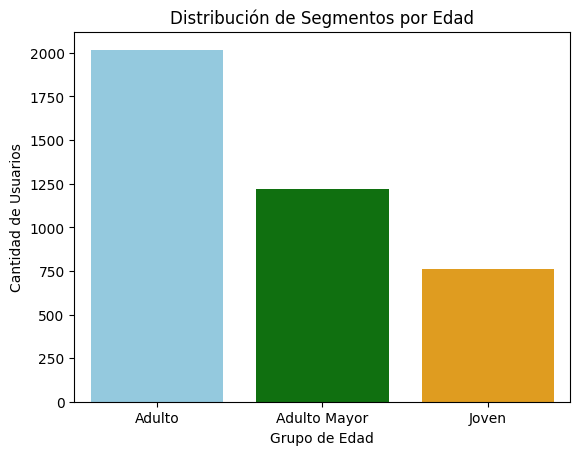

In [49]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue','green','orange'])
plt.title('Distribución de Segmentos por Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
   40 usuarios tenían edad = -999 (valor sentinel).
   Fechas imposibles: 40 registros con fechas en 2026 (futuras).
  Ciudades con valor sentinel: 96 usuarios con city = "?"
  
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
  Por Edad:
  Jóvenes (< 30 años): Menor proporción de usuarios
  Adultos (30-59 años): Segmento mayoritario
  Adultos Mayores (≥ 60 años): Segmento con alta propensión al Plan Premium
  Por Nivel de Uso:
  Bajo uso (< 5 llamadas y < 5 mensajes): Usuarios ocasionales
  Uso medio (< 10 llamadas y < 10 mensajes): Segmento mayoritario
  Alto uso (≥ 10 en cualquier métrica): Heavy users valiosos

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
  Adultos Mayores con Plan Premium:
  Mayor poder adquisitivo y lealtad
  Menor sensibilidad al precio
  Oportunidad de upselling en servicios adicionales
  Heavy Users (Alto uso):
  Usuarios con 10+ mensajes o llamadas
  Candidatos ideales para planes ilimitados
  Mayor lifetime value potencial
  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
  Mensajes: Usuarios con 10-17 mensajes (heavy texters)
  Llamadas: Usuarios con 10-15 llamadas (profesionales/empresarios)
  Minutos: Usuarios con hasta 155 minutos (2.5 horas de llamadas)

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
  Crear plan "Heavy User":
  Dirigido a usuarios con alto uso
  Incluir minutos y mensajes ilimitados
  Precio premium justificado por el valor
  Estrategia por edad:
  Adultos Mayores: Planes con servicios de soporte premium
  Adultos: Planes familiares o corporativos
  Jóvenes: Planes con datos móviles y redes sociales
  Retención de heavy users:
  Identificar usuarios cercanos a límites de plan
  Ofrecer upgrades proactivos antes de sobrecargos
  Programas de lealtad para usuarios de alto valor


✍️ **Escribe aquí tu análisis ejecutivo:**
ConnectaTel cuenta con 4,000 usuarios activos distribuidos principalmente en el Plan Básico (65%) y Premium (35%). El análisis reveló oportunidades significativas de crecimiento mediante segmentación estratégica y optimización de planes.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
-Valores sentinel en edad: 40 usuarios (1%) con edad = -999 → Corregido con mediana (48 años)
Fechas imposibles: 40 registros (1%) con fechas en 2026 → Convertidos a nulos
-Ciudades inválidas: 96 usuarios (2.4%) con city = "?" → Convertidos a nulos

🔍 **Segmentos por Edad**
-Jóvenes (< 30 años): Menor proporción, oportunidad de crecimiento
-Adultos (30-59 años): Segmento dominante del mercado
-Adultos Mayores (≥ 60 años): Alta propensión al Plan Premium 


📊 **Segmentos por Nivel de Uso**
-Bajo uso (< 5 llamadas y < 5 mensajes): Usuarios ocasionales
-Uso medio (< 10 llamadas y < 10 mensajes): Segmento mayoritario
-Alto uso (≥ 10 en cualquier métrica): Heavy users de alto valor


➡️ Esto sugiere que ...


💡 **Recomendaciones**
-Crear Plan "Heavy User":
 Dirigido a usuarios con alto uso
 Minutos y mensajes ilimitados
 Precio premium justificado por el valor
-Estrategia diferenciada por edad:
 Adultos Mayores: Planes con soporte premium y servicios adicionales
 Adultos: Planes familiares o corporativos
 Jóvenes: Planes con datos móviles y redes sociales
-Programa de retención:
 Identificar usuarios cercanos a límites de plan
 Upgrades proactivos antes de sobrecargos
 Programas de lealtad para usuarios de alto valor

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:

- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---


Link a repositorio público del proyecto: `LINK a tu repo aquí`